# Exploratory Data Analysis (EDA) - Titanic Dataset

## Introduction

In this notebook, I perform a complete Exploratory Data Analysis (EDA) on the Titanic dataset. The goal is to understand the dataset, identify potential data quality issues, explore feature distributions, analyze relationships between variables, and summarize the findings before building a machine learning model.

---

## 1. Dataset Overview

- Load the dataset.
- Display the first few rows.
- Check the dataset shape.
- Inspect data types and missing values.

**Observation:**

The dataset contains passenger information such as age, fare, passenger class, family relationships, and survival status. Some columns contain missing values that must be handled before modeling.

---

In [23]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('../../week1/day4/train.csv')
print(df.shape)
print(df.info())
df.head()

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Descriptive Statistics

- `df.describe()`
- Mean
- Median
- Standard deviation
- Quartiles

**Observation:**

The descriptive statistics provide an overview of the numeric features. For example, the average passenger age is around 30 years, while the fare has a much larger spread, indicating high variability.

---

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Univariate Analysis

### Age Distribution
**Observation:**

Most passengers were between 20 and 40 years old, with relatively few elderly passengers.

<Axes: xlabel='Age', ylabel='Count'>

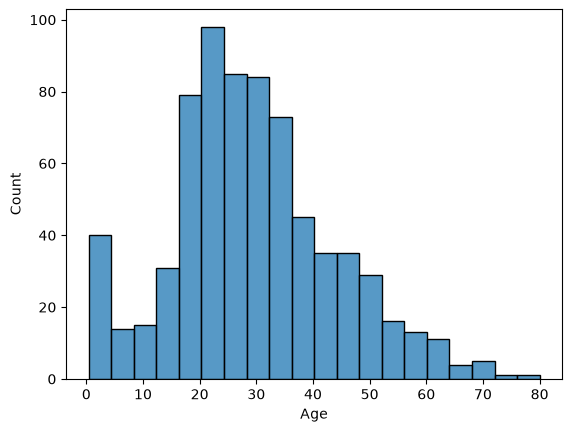

In [16]:
sns.histplot(data=df,x='Age')

### Fare Distribution


**Observation:**

The fare distribution is highly right-skewed because only a small number of passengers paid very expensive fares.


<Axes: xlabel='Fare', ylabel='Count'>

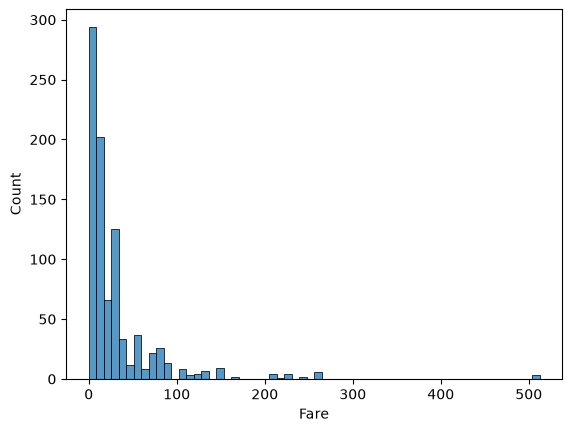

In [17]:
sns.histplot(data=df,x='Fare')

### Sex Distribution

**Observation:**

There are considerably more male passengers than female passengers.

<Axes: xlabel='Sex', ylabel='count'>

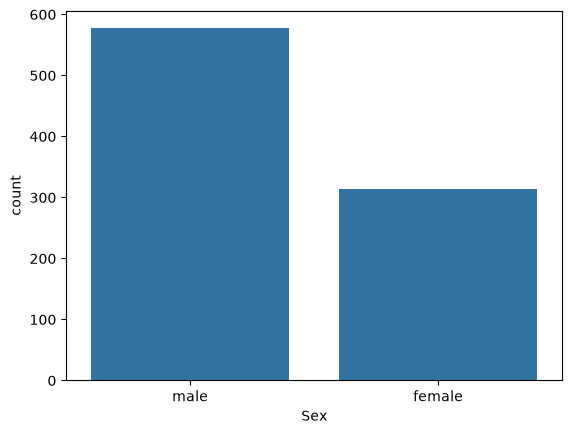

In [18]:
sns.countplot(data=df,x='Sex')

## 4. Outlier Detection

**Observation:**

The IQR method detected several passengers older than approximately 65 years as potential outliers. These values are realistic and represent elderly passengers rather than data errors, so they were kept in the dataset.

---

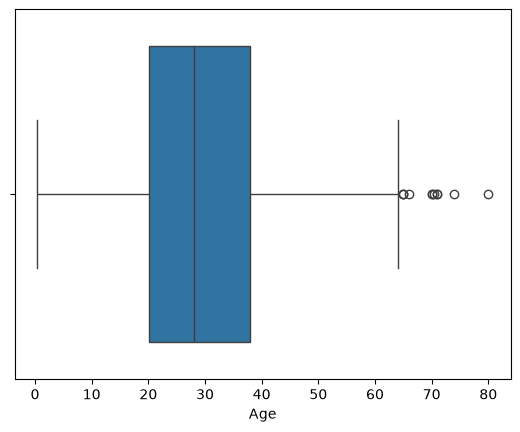

33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64
Q1 = 20.125
Q3 = 38.0
IQR = 17.875
Lower Bound = -6.6875
Upper Bound = 64.8125


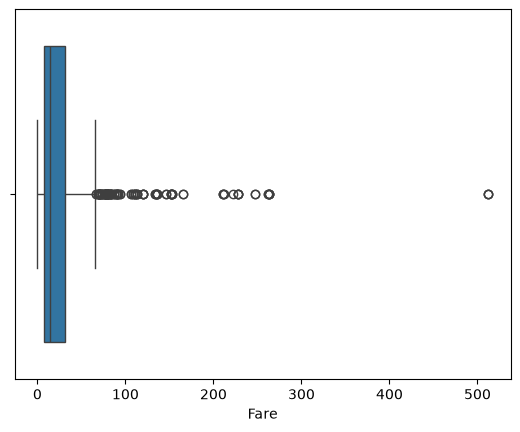

In [26]:
sns.boxplot(data=df,x="Age")
plt.show()
sns.boxplot(data=df,x="Fare")
age = df['Age']
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = age[
    (age < lower_bound) |
    (age > upper_bound)
]

print(outliers)
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

## 5. Bivariate Analysis

**Observation:**

The scatter plot shows the relationship between Age and Fare. While no strong linear relationship is visible, the grouped box plots reveal differences in fare across passenger classes.

---


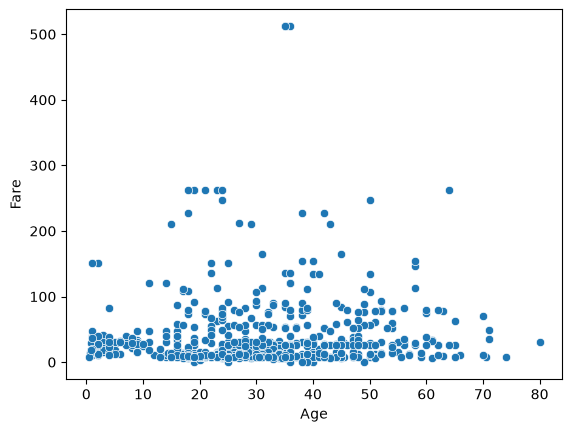

<Axes: xlabel='Pclass', ylabel='Fare'>

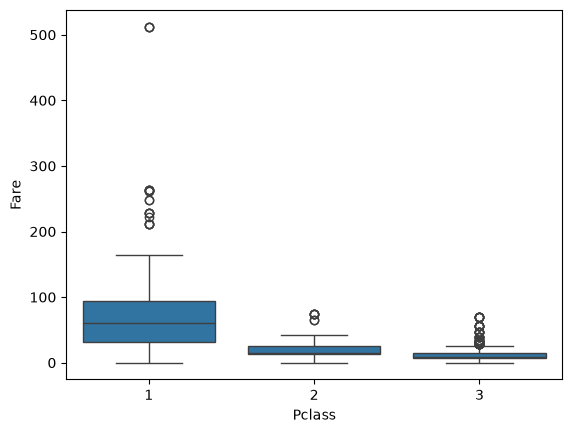

In [20]:
sns.scatterplot(data=df, x="Age", y="Fare")
plt.show()
sns.boxplot(data=df, x="Pclass", y="Fare")

## 6. Correlation Analysis
**Observation:**

The strongest relationships include:

- A strong negative correlation between **Fare** and **Pclass**, indicating that passengers in higher classes generally paid higher fares.
- A positive correlation between **SibSp** and **Parch**, as both features describe family members traveling together.

These relationships may be useful for feature engineering and predictive modeling.

---

<Axes: >

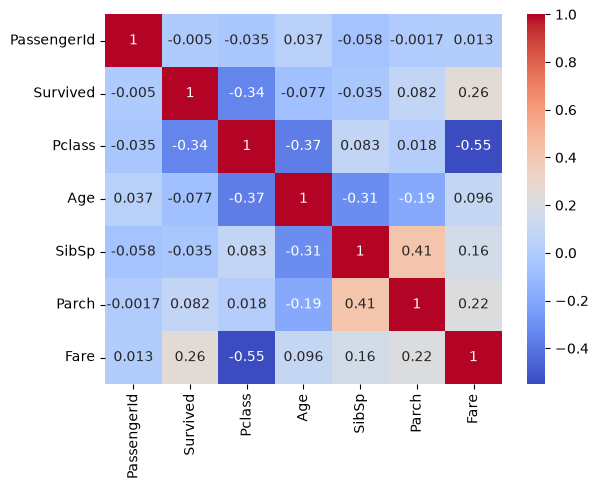

In [21]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

### 7. Survival Rate by Sex and Passenger Class

This grouped bar plot compares survival rates across passenger sex and class.

**Observation:**

 First-class passengers generally had the highest survival rates, while third-class passengers had the lowest, especially among males. This suggests that both `Sex` and `Pclass` are important features for predicting survival.

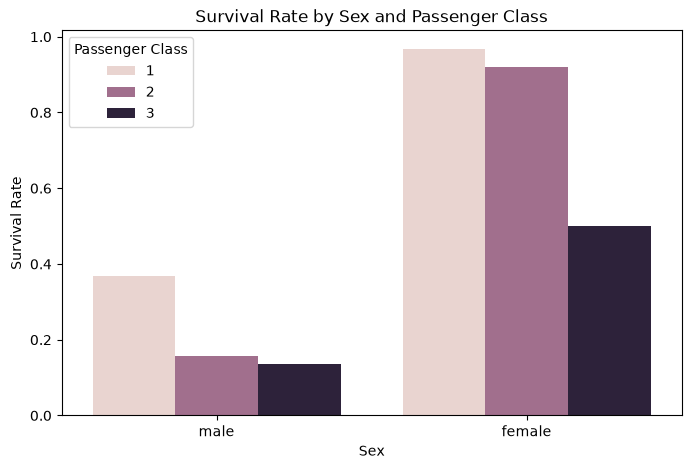

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    hue="Pclass",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.legend(title="Passenger Class")
plt.show()

## 8. Data Storytelling

From this analysis, several important insights:

- Most passengers were young adults between 20 - 40 years old.
- Ticket fares are heavily skewed because only a few passengers paid very high prices.
- Elderly passengers were identified as statistical outliers but represent valid observations.
- Passenger class strongly influences ticket fare.
- Family-related features (`SibSp` and `Parch`) are positively related and could be combined into a new feature such as `FamilySize`.
- These findings provide a better understanding of the dataset and will help guide feature selection and preprocessing before training machine learning models.
- Female passengers had higher survival rates than male passengers across all classes. And this was cuz the female was rescued before the males. 
---

## Conclusion

The EDA revealed the overall structure of the Titanic dataset, identified valid outliers, explored feature distributions, and highlighted important relationships between variables. This analysis provides a solid foundation for data preprocessing, feature engineering, and building predictive machine learning models.

# Driver Shift Module — Current State, Analysis, and Recommendation

Status: **review document** (not yet an accepted ADR)
Scope: `DriverShift`, `DriverProfile.availability`, `DriverDailyStats.onlineMinutes`, driver location heartbeat
Question being answered: *should the driver keep two controls (start shift + set available), or just one ON/OFF toggle?*

**Short answer: collapse to one toggle.** The shift is already a derived concept in this codebase — it is opened and closed automatically by every availability write, it is not read by ride matching, and its UI card is already commented out. Making it a second thing the driver has to think about buys nothing and currently costs correctness. The rest of this document is the evidence, the risks that must be fixed either way, and the migration.

---

## 1. What exists today

### 1.1 Two overlapping state concepts

| | `DriverProfile.availability` | `DriverShift` |
|---|---|---|
| Type | enum `OFFLINE \| AVAILABLE \| BUSY` (`enums.prisma:224`) | row with `startedAt`, `endedAt`, `startReason`, `endReason` (`driver.prisma:92`) |
| Cardinality | one value per driver | many rows per driver; at most one "open" (`endedAt == null`) |
| Meaning | *can this driver be offered a ride right now* | *was this driver clocked in during this time window* |
| Written by | driver toggle, ride lifecycle, trip lifecycle, location ping | `ensureOpenShift` / `closeOpenShift`, always as a side effect of an availability write |
| Read by matching | **yes** — hard gate | **no** — never referenced |

### 1.2 Where availability is the gate

Candidate generation and assignment filter on availability and nothing else shift-related:

- `candidates.service.ts` → `fetchAvailableShortlist` / `fetchBusyShortlist`
- `assignment.service.ts:670` and `:752` — `AND dp."availability" = 'AVAILABLE'`

There is **no** `DriverShift` join anywhere in `backend/src/rides`. Confirmed by grep: the only non-spec references to `driverShift` outside `drivers-shifts.service.ts` are none.

**Consequence: a driver with no open shift who is `AVAILABLE` is fully matchable.** The shift does not gate anything on the server.

### 1.3 What the shift is actually used for

Three consumers, all downstream reporting/UX — none authoritative:

1. **`DriverDailyStats.onlineMinutes`** — `recomputeTodayOnlineMinutes` (`drivers-shifts.service.ts:393`) sums today's clipped shift intervals and upserts the daily row. Surfaced on the driver dashboard as `today.onlineMinutes` (`drivers.service.ts:320`).
2. **Gamification** — `syncOnlineHoursProgress` → `handleOnlineHoursAbsolute` → `MissionType.ONLINE_HOURS` progress (`drivers-missions.service.ts:641`).
3. **Mobile location heartbeat gate** — `main_shell.dart` starts/stops the 5-second location timer on `app.driverShiftOpen` (`:515`, `:576`, `:601`, `:625`).

Item 3 is the only place where the shift has *operational* consequence, and as shown in §3.1 it is gated on the wrong signal.

### 1.4 The shift is already fully automatic

Every path that changes availability also maintains the shift:

| Trigger | Availability write | Shift side effect |
|---|---|---|
| `POST /driver/set-availability {AVAILABLE\|BUSY}` | set as given | `ensureOpenShift` (`:76`) |
| `POST /driver/set-availability {OFFLINE}` | `OFFLINE` | `closeOpenShift(MANUAL)` (`:74`) |
| `POST /driver/shift/start` | forced `AVAILABLE` (`:98`) | `ensureOpenShift` (`:93`) |
| `POST /driver/shift/end` | forced `OFFLINE` (`:122`) | `closeOpenShift(MANUAL)` (`:117`) |
| `POST /driver/location` while `OFFLINE` | flipped to `AVAILABLE` (`:178-189`) | `ensureOpenShift` (`:193`) |
| Ride completed / cancelled | `AVAILABLE` (`lifecycle.service.ts:321`, `cancellation.service.ts:229`) | none (shift already open) |
| Trip accept/complete | `AVAILABLE`/`BUSY` (`drivers-trips.service.ts:309`) | none |

Read the first four rows together: **`shift/start` is byte-for-byte equivalent to `set-availability {AVAILABLE}`, and `shift/end` is equivalent to `set-availability {OFFLINE}`.** They are duplicate endpoints for the same state transition. There is no reachable state where "shift open + OFFLINE" or "shift closed + AVAILABLE" is produced deliberately — only by the bugs in §3.

### 1.5 The dual UI is already dead

`clients/mobile/lib/delivery/driver_home_screen.dart:261-264` — the `_DriverShiftCard` render is commented out. The `_DriverShiftCard` widget (`:1046`), `startDriverShift` / `endDriverShift` (`app_state_driver.part.dart:306`, `:328`), and the `/driver/shift/*` API bindings (`driver_rides_api.dart:16-18`, `:51-53`) are all still live code with no entry point.

**So the driver today already sees only one control** — the toggle at `driver_home_screen.dart:473`. The confusion the question describes is a property of the *API and state model*, not of what the driver currently sees. That is good news for the migration: the client change is mostly deletion.

---

## 2. Answering the question directly

> Is it better to keep only AVAILABLE / OFFLINE?

**Yes, for the driver-facing model.** Reasons, in order of weight:

1. **A second control with no distinct meaning is pure cognitive cost.** The driver's mental model — *ON = I get rides, OFF = I don't* — is exactly correct and exactly what the server enforces. "Start shift" adds a step whose only observable effect is the same as the toggle. Two controls that do the same thing teach drivers that the app is unpredictable.

2. **There is no business rule that needs attendance separate from availability.** A separate shift concept earns its keep when something depends on *scheduled attendance*: office-assigned shift rosters, payroll by clocked hours, shift-based commission tiers, or "you may not go online outside your shift window." None of these exist in this codebase. `DriverShiftStartReason.AUTO`, `DriverShiftEndReason.OFFLINE`, `BLOCKED`, and `APP_KILLED` are all declared and never used — the enum was designed for a richer model that was never built.

3. **The `BUSY` state must stay, but it is not a driver control.** `BUSY` is written by the system when the driver has an active ride/trip (`drivers-trips.service.ts:309`), and it is what makes PD-14 queued candidates work. The driver should never set it. So the driver-facing model is a **boolean**, while the stored enum stays ternary.

4. **Keeping `DriverShift` as a table is still correct** — you need an interval ledger to compute `onlineMinutes` and `ONLINE_HOURS` missions. `availability` alone is a point-in-time value with no history. The fix is not to delete the table; it is to stop exposing it as a driver action.

**Recommended model:**

```
Driver-facing:   [ ON ] ←→ [ OFF ]          (one toggle; plus a read-only "On a ride" chip when BUSY)
Stored state:    availability: OFFLINE | AVAILABLE | BUSY
Derived ledger:  DriverShift — opened when availability leaves OFFLINE,
                 closed when it enters OFFLINE. Never a driver action.
```

Invariant to enforce and test: **`availability != OFFLINE` ⟺ exactly one open `DriverShift` row.**

---

## 3. Defects found while reviewing (these need fixing regardless of the decision)

These are ordered by severity. Items 3.1–3.3 are live correctness problems today.

### 3.1 Location heartbeat is gated on stale client shift state — HIGH

`main_shell.dart` gates the 5-second location timer on `app.driverShiftOpen` (`:515`, `:576`, `:601`, `:625`), which is `_driverCurrentShift != null` (`app_state.dart:406`).

`setDriverAvailability` (`app_state_driver.part.dart:382-426`) updates `_driverProfile.availability` but **never refreshes `_driverCurrentShift`**. The server did open a shift; the client does not know.

Failure: driver toggles ON → server has `AVAILABLE` + open shift → client still has `driverShiftOpen == false` → **no location pings are sent**. The driver appears online in candidate SQL but with a stale `DriverLocation`. Recovery only happens incidentally, if the driver pulls-to-refresh the home screen (`driver_home_screen.dart:79`) or the shell re-attaches (`main_shell.dart:502`).

This is currently masked by §3.4 — the location freshness filter is commented out of the candidate query, so stale-located drivers still match. Restoring that filter without fixing this will make toggled-on drivers invisible to matching.

**Fix:** gate the heartbeat on `driverAvailability != 'OFFLINE'`, not on `driverShiftOpen`. Availability is the signal the client actually owns and updates optimistically.

### 3.2 A location ping resurrects a driver who went offline — HIGH

`drivers-shifts.service.ts:178-194`:

```ts
const nextAvailability =
  profile.availability === DriverAvailability.OFFLINE
    ? DriverAvailability.AVAILABLE
    : profile.availability;
```

Any `POST /driver/location` from an `OFFLINE` driver silently flips them to `AVAILABLE` **and opens a new shift**. An in-flight ping racing the toggle-off, a background location callback, or a retry after the driver goes offline all put the driver back on duty without any user action — and start accruing online minutes.

This directly contradicts the semantics the toggle promises ("OFF = I am not receiving rides"), and it is the single most likely cause of "I turned it off and still got a ride" reports.

**Fix:** a location ping must never change availability. If the driver is `OFFLINE`, either reject the ping (`409`) or accept it as pure telemetry — update `lastSeenAt`/`DriverLocation` and do not touch `availability` or open a shift.

### 3.3 Nothing ever closes an abandoned shift — HIGH (data integrity)

There is no scheduled job in the backend (`grep -rn "Cron\|@Interval" backend/src` → no results). `DriverShiftEndReason.APP_KILLED`, `.OFFLINE`, and `.BLOCKED` are declared and never written — only `MANUAL` is used (`:74`, `:117`).

Failure: driver force-quits the app, loses the phone, or drops connectivity while `AVAILABLE`. The shift stays open forever. `recomputeTodayOnlineMinutes` computes `endedAt ?? now` (`:425`), so:

- `onlineMinutes` grows without bound for as long as the row stays open — up to the full 24h clip per day, every day.
- `ONLINE_HOURS` missions and any online-hours-based rewards get credited for time the driver was not working.
- The driver also stays `AVAILABLE` in candidate SQL, so they keep getting offered rides they cannot accept — which then burns candidate generations and slows passenger matching.

**Fix:** a periodic reaper. Any driver whose `lastSeenAt` is older than a stale threshold (suggest 3–5× the heartbeat, so ~2–5 minutes) gets `availability = OFFLINE` and `closeOpenShift(APP_KILLED)`, with `endedAt` backdated to `lastSeenAt` rather than `now` so the minutes are not inflated. This is what `APP_KILLED` was clearly designed for.

### 3.4 Candidate location-freshness filter is disabled — MEDIUM

`candidates.service.ts:331-334`:

```ts
const freshnessCutoff = new Date(Date.now() - DRIVER_LOCATION_FRESHNESS_SECONDS * 1000);
//malik back here to return
//        AND (dl."recordedAt" AT TIME ZONE 'UTC') >= ${freshnessCutoff}
```

`freshnessCutoff` is computed and unused. `DRIVER_LOCATION_FRESHNESS_SECONDS = 1000` (`rides.constants.ts:5`) — ~16.7 minutes, against a 5-second heartbeat, which looks like a debugging value rather than a deliberate one.

With §3.3 unfixed, restoring this clause is the *only* thing preventing permanently-online ghost drivers from matching. With §3.3 fixed, freshness becomes a defence-in-depth check. Note the ordering dependency: fix §3.1 before restoring this, or genuinely-online drivers get filtered out.

### 3.5 Dashboard online minutes are stale — LOW

`drivers.service.ts:208-209` — the `refreshTodayOnlineMinutes` call in `getDashboard` is commented out. `onlineMinutes` therefore reflects the last availability *write*, not now. A driver online for three hours without toggling sees the value frozen at whatever it was when they turned on (i.e. ~0).

**Fix:** either restore the refresh call, or compute the open-shift tail on read (`onlineMinutes + minutesSince(openShift.startedAt)`) without a write. The read-side computation is preferable — see §3.6.

### 3.6 Every location ping runs a full-day recompute — MEDIUM (performance)

`updateLocation` (`:183-200`) opens a transaction, updates the profile, runs `recomputeTodayOnlineMinutes` (which queries all of today's shifts and upserts `DriverDailyStats`), then calls `syncOnlineHoursProgress` → missions progress write. At a 5-second heartbeat (`main_shell.dart:121`) that is **~720 transactions + 720 mission writes per driver per hour**, all to recompute a number that only changes when a shift boundary moves.

Worse, this happens on the hot path of every ping *before* the early-return guards at `:210` and `:225` — so even pings that are dropped as duplicate/too-frequent pay the full cost.

**Fix:** recompute online minutes on shift-boundary transitions only (open/close), plus on read for the open tail. Drop it from the ping path entirely; the ping should only write `lastSeenAt` + `DriverLocation`.

### 3.7 The shift invariant is not centrally enforced — LOW

`lifecycle.service.ts:321` and `cancellation.service.ts:229` write `availability = AVAILABLE` directly via Prisma, bypassing `DriversShiftsService`. Today this is harmless (the driver already had an open shift). But it means the §2 invariant is upheld by convention, not construction — a future path that sets `AVAILABLE` on a driver with no open shift would silently produce an inconsistent state and lose the minutes.

**Fix:** route availability writes through a single `DriversShiftsService.applyAvailability(tx, driverId, next)` helper that owns the shift side effect, and have the ride/trip services call it.

### 3.8 Minor

- `DriverShiftStartReason` is never set explicitly — every row defaults to `MANUAL`, including the auto-opened ones from `updateLocation`. If §3.2 is fixed as recommended, `AUTO` becomes dead and should be dropped from the enum.
- `drivers-shifts.service.ts:11` carries a stale Arabic TODO comment (`// <-- إذا عندك enum في Prisma`) on a `DriverShiftEndReason` import that does resolve.
- `syncOnlineHoursProgress` (`:471`) guards with `typeof this.drivers.handleOnlineHoursAbsolute === 'function'` — a runtime check against a statically-typed method, presumably a leftover from the `forwardRef` circular-dependency work. It hides real wiring failures.

---

## 4. Recommended target design

### 4.1 Driver-facing contract

One toggle. Three display states, one of which is not settable:

| Display | Stored | Set by |
|---|---|---|
| **ON — receiving rides** | `AVAILABLE` | driver toggle |
| **On a ride** (read-only chip) | `BUSY` | system, on ride/trip assignment |
| **OFF — not receiving** | `OFFLINE` | driver toggle, or the stale reaper |

Optional supporting display, from the open shift: *"Online since 07:40 · 3h 12m today"* — informational, not a control.

### 4.2 API surface

| Endpoint | Action |
|---|---|
| `POST /driver/set-availability` | **Keep.** The single write path. Restrict the DTO to `AVAILABLE \| OFFLINE`; reject `BUSY` from clients with `400` — only the system sets it. |
| `POST /driver/shift/start` | **Deprecate, then remove.** Equivalent to `set-availability {AVAILABLE}`. |
| `POST /driver/shift/end` | **Deprecate, then remove.** Equivalent to `set-availability {OFFLINE}`. |
| `GET /driver/shift/current` | **Keep**, or fold into `/driver/dashboard` as `today.onlineSince`. Read-only, for the "online since" display. |
| `POST /driver/location` | **Change.** Must not mutate `availability` or open shifts (§3.2). |

Because `shift/start` and `shift/end` have no live caller in the mobile client (§1.5), they can be deleted outright once the dead client code goes — no deprecation window is needed for first-party apps. Keep the window only if a third-party or older build might still call them.

### 4.3 Server-side rules

1. `DriversShiftsService.applyAvailability(tx, driverId, next)` becomes the only place `availability` is written. It opens a shift on `OFFLINE → {AVAILABLE, BUSY}` and closes one on `{AVAILABLE, BUSY} → OFFLINE`. All ride/trip lifecycle code calls it (§3.7).
2. Location pings write `lastSeenAt` + `DriverLocation` only.
3. A reaper job (every ~60s) marks drivers stale by `lastSeenAt` → `OFFLINE` + `closeOpenShift(APP_KILLED, endedAt = lastSeenAt)` (§3.3).
4. `onlineMinutes` is recomputed on shift-boundary transitions and on dashboard read (open tail added live), never on the ping path (§3.6).
5. Restore the candidate freshness clause and set `DRIVER_LOCATION_FRESHNESS_SECONDS` to a deliberate value — suggest 120s, ~24× the heartbeat, generous enough for a tunnel or a brief background suspension (§3.4).

### 4.4 Client changes

- Delete `_DriverShiftCard`, `startDriverShift`, `endDriverShift`, and the `startShift`/`endShift` bindings in `driver_rides_api.dart`.
- Replace `driverShiftOpen` as the heartbeat gate with `driverAvailability != 'OFFLINE'` (§3.1).
- Keep `loadDriverCurrentShift` **only** if the "online since" display is wanted; otherwise delete it and read the value from the dashboard.
- Toggle stays optimistic (it already is, `app_state_driver.part.dart:393-405`), with rollback on failure — that behaviour is correct and should be preserved.

---

## 5. Migration order

Sequencing matters — §3.1 must land before §3.4, or matching breaks for toggled-on drivers.

1. **Server, no behaviour change:** introduce `applyAvailability`, route ride/trip lifecycle writes through it, add tests for the §2 invariant.
2. **Fix §3.2** — location ping stops mutating availability. Ship with §3 below, or drivers with the current client stop pinging.
3. **Fix §3.1** — client heartbeat gates on availability. Ship together with step 2.
4. **Add the reaper (§3.3)** — start with logging-only for a day to size the stale threshold against real `lastSeenAt` distributions before it starts flipping drivers offline.
5. **Move the recompute off the ping path (§3.6)** and fix the dashboard read (§3.5).
6. **Restore the freshness clause (§3.4)** with a deliberate constant — only after steps 3 and 4 are confirmed in production.
7. **Delete the shift endpoints and dead client code (§4.2, §4.4).**

Steps 1–3 are the ones that fix live bugs. Step 7 is the actual answer to the original question and is the cheapest of the set — most of the work is deletion.

## 6. When to revisit

Reintroduce a first-class shift concept only if the business adds a rule that depends on *scheduled* attendance rather than *current* willingness — office-assigned rosters, payroll by clocked hours, shift-window enforcement, or shift-tier commissions. At that point the shift becomes a planned interval with its own lifecycle, and availability becomes the driver's moment-to-moment state *within* it. That is a genuinely two-concept model. Nothing in the current scope requires it, and building it early is what produced the current ambiguity.
